## Compressor

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from vclibpy.components.compressors import ConstantEffectivenessCompressor
from vclibpy.media import RefProp
from vclibpy import FlowsheetState, Inputs, RelativeCompressorSpeedControl

# ==========================================
# SETUP & PARAMETERS
# ==========================================

REFPROP_DIR = r"C:\Program Files (x86)\REFPROP"
REFPROP_DLL = r"C:\Program Files (x86)\REFPROP\REFPRP64.DLL"
os.environ["RPPREFIX"] = REFPROP_DIR

# Initialize Fluid Media
RP = RefProp(
    fluid_name="Propane",
    dll_path=REFPROP_DLL,
    ref_prop_path=REFPROP_DIR
)


# Initialize Compressor
compressor = ConstantEffectivenessCompressor(
    N_max=120,          # Max speed in Hz (rps) - arbitrary limit for scaling
    V_h=19e-6,          # Displacement volume [m^3]
    eta_isentropic=0.7, # Isentropic efficiency
    eta_mech=0.9,       # Mechanical efficiency
    lambda_h=0.9        # Volumetric efficiency
)
compressor.RP = RP

# Operating Conditions (Inputs)
P_EVAP = 5e5        # Evaporation Pressure [Pa]
SUPERHEAT = 10.0    # Superheat [K]
p_cond = 15e5       # Condensing/Discharge Pressure [Pa]
SPEED_REL = 0.5     # Relative Compressor Speed (0.0 - 1.0)


# ==========================================
# CALCULATION ROUTINE
# ==========================================

# Initialize Simulation Objects
fs_state = FlowsheetState()
inputs = Inputs(control=RelativeCompressorSpeedControl(n=SPEED_REL))

# Set Inlet State
T_sat_inlet = med_prop.calc_state("PQ", P_EVAP, 1.0).T 
T_inlet = T_sat_inlet + SUPERHEAT
compressor.state_inlet = med_prop.calc_state("PT", P_EVAP, T_inlet)

# Calculate Mass Flow
m_flow = compressor.calc_m_flow(inputs=inputs, fs_state=fs_state)

# Calculate Outlet State
compressor.calc_state_outlet(
    p_outlet=p_cond, 
    inputs=inputs, 
    fs_state=fs_state
)
T_out = compressor.state_outlet.T
h_out = compressor.state_outlet.h

# Calculate Power
P_el = compressor.calc_electrical_power(inputs=inputs, fs_state=fs_state)


# ==========================================
# RESULTS OUTPUT
# ==========================================

print("-" * 40)
print(f"COMPRESSOR SIMULATION REPORT")
print("-" * 40)

print(f"INPUTS:")
print(f"  Speed Setpoint:   {SPEED_REL*100:.1f} %")
print(f"  P_evap:           {P_EVAP/1e5:.2f} bar")
print(f"  Superheat:        {SUPERHEAT:.1f} K")
print(f"  p_cond (Target):  {p_cond/1e5:.2f} bar")

print("-" * 40)
print(f"RESULTS:")
print(f"  Outlet Temp:      {T_out-273.15:.2f} °C")
print(f"  Outlet Enthalpy:  {h_out/1000:.2f} kJ/kg")
print(f"  Mass Flow:        {m_flow:.6f} kg/s")
print(f"  Elec. Power:      {P_el:.1f} W")
print("-" * 40)

## Condenser

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

# VcLibPy Imports
from vclibpy.components.heat_exchangers import MovingBoundaryNTUCondenser
from vclibpy.components.heat_exchangers.heat_transfer.constant import (
    ConstantHeatTransfer, ConstantTwoPhaseHeatTransfer
)
from vclibpy.components.heat_exchangers.heat_transfer.wall import WallTransfer
from vclibpy.media import RefProp, CoolProp
from vclibpy import FlowsheetState, Inputs, RelativeCompressorSpeedControl, HeatExchangerInputs

# ==========================================
# SETUP & CONFIGURATION
# ==========================================

# --- Optional: RefProp Setup (Uncomment/Adjust if you have RefProp) ---
REFPROP_DIR = r"C:\Program Files (x86)\REFPROP"
REFPROP_DLL = r"C:\Program Files (x86)\REFPROP\REFPRP64.DLL"
os.environ["RPPREFIX"] = REFPROP_DIR
med_prop = RefProp(fluid_name="Propane", dll_path=REFPROP_DLL, ref_prop_path=REFPROP_DIR)

# Instantiate the Condenser
condenser = MovingBoundaryNTUCondenser(
    A=2.5,
    secondary_medium="Water",
    flow_type="counter",
    ratio_outer_to_inner_area=1.0,
    two_phase_heat_transfer=ConstantTwoPhaseHeatTransfer(alpha=6000), 
    gas_heat_transfer=ConstantHeatTransfer(alpha=800),
    liquid_heat_transfer=ConstantHeatTransfer(alpha=1000),
    wall_heat_transfer=WallTransfer(lambda_=16, thickness=0.002), 
    secondary_heat_transfer=ConstantHeatTransfer(alpha=3000) 
)

condenser.med_prop = med_prop
condenser.start_secondary_med_prop() 

# ==========================================
# DEFINE INPUTS & TARGETS
# ==========================================

fs_state = FlowsheetState()

# Operational Parameters
T_water_in = 273.15 + 25.0   # Water Inlet [°C]
dT_subcooling = 5.0          # Target Subcooling: [K]
m_flow_ref = 0.05            # Refrigerant Mass Flow [kg/s]
m_flow_water = 0.25          # Water Mass Flow [kg/s]
T_hot_gas = 273.15 + 85.0    # Compressor Discharge Temp (Inlet)

# Set component flows
condenser.m_flow = m_flow_ref             # Refrigerant flow
condenser.m_flow_secondary = m_flow_water # Water flow
condenser.calc_secondary_cp(T=T_water_in, p=1e5)

# Define Inputs Wrapper
inputs = Inputs(
    control=RelativeCompressorSpeedControl(
        dT_eva_superheating=10,         # Not used by condenser directly, but required by struct
        dT_con_subcooling=dT_subcooling
    ),
    condenser=HeatExchangerInputs(
        T_in=T_water_in, 
        m_flow=m_flow_water
    )
)

# ==========================================
# 3. ITERATION LOOP
# ==========================================
# Goal: Find the Condensation Pressure (p_cond) that satisfies the heat transfer equations.
# We compare the Required Heat (Q_target) vs Possible Heat (Q_NTU).

print("-" * 50)
print("Starting Condenser Iteration (Moving Boundary)")
print("-" * 50)

# Initial Guess
p_cond_guess = med_prop.calc_state("TQ", 273.15 + 45, 1).p # Start guessing at 45°C sat
max_iterations = 100
n_iteration = 0
p_step = 10000.0   # 10 kPa initial step
min_step = 1.0     # 1 Pa precision
min_error = 0.1    # 0.1% error tolerance

# Storage for plotting
history_error = []
history_p_cond = []
history_Q = []

p_current = p_cond_guess

while n_iteration < max_iterations:
    # 1. Define Inlet State (Superheated Vapor)
    #    We assume fixed T_inlet and P_current (simulating compressor discharge)
    condenser.state_inlet = med_prop.calc_state("PT", p_current, T_hot_gas)
    
    # 2. Define Target Outlet State (Subcooled Liquid)
    #    T_sat - Subcooling
    T_sat = med_prop.calc_state("PQ", p_current, 0).T
    condenser.state_outlet = med_prop.calc_state("PT", p_current, T_sat - dT_subcooling)
    
    # 3. Calculate Heat Transfer
    #    Returns error = (Q_ntu / Q_target - 1) * 100
    error, _ = condenser.calc(inputs=inputs, fs_state=fs_state)
    Q_flow = condenser.calc_Q_flow()
    
    # Store history
    history_error.append(error)
    history_p_cond.append(p_current / 1e5)
    history_Q.append(Q_flow)
    
    n_iteration += 1

    # 4. Convergence Check & Update
    # Logic: If Error < 0, Q_ntu < Q_required. The HEX is "too small" for current conditions.
    # To transfer MORE heat, we need a larger Delta T.
    # Since Water Temp is fixed, we must RAISE Condensation Temp (Pressure).
    
    if abs(error) < min_error:
        print(f"Converged in {n_iteration} iterations.")
        break
    
    if error < -min_error:
        # NTU capability too low -> Increase Pressure/Temp to drive more heat
        p_current += p_step
    elif error > min_error:
        # NTU capability too high -> Decrease Pressure/Temp
        p_current -= p_step
        
        # Adaptive step size: If we overshoot (change direction), reduce step
        if len(history_error) > 1 and (history_error[-1] * history_error[-2] < 0):
             p_step /= 5.0
             
    if p_step < min_step:
        print("Warning: Min step size reached.")
        break
else:
    print("Did not converge within max iterations.")

print(f"Final Result: p_cond={p_current/1e5:.4f} bar, Error={error:.4f}%")
print(f"Heat Condensation: {condenser.calc_Q_flow()/1000:.2f} kW")


# ==========================================
# 4. PLOTTING RESULTS
# ==========================================

# --- Plot 1: Convergence ---
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(8, 6))
ax[0].plot(range(n_iteration), history_error, marker=".")
ax[0].axhline(0, color='k', linestyle='--', linewidth=0.8)
ax[0].set_ylabel("Error [%]")
ax[0].set_title("Iteration Convergence")
ax[0].grid(True, alpha=0.3)

ax[1].plot(range(n_iteration), history_p_cond, marker=".", color="orange")
ax[1].set_ylabel("$p_{cond}$ [bar]")
ax[1].set_xlabel("Iteration Step")
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: Pinch Point / T-h Diagram ---
# Get saturation curve
limits_h = med_prop.get_two_phase_limits("h") / 1000
limits_T = med_prop.get_two_phase_limits("T") - 273.15

plt.figure(figsize=(8, 6))

# 1. Saturation Dome
plt.plot(limits_h, limits_T, color="black", linewidth=1, label="Saturation Curve")

# 2. Refrigerant Process Line (Hot Gas -> Condensing -> Subcooled)
# Create intermediate points for prettier plotting
h_in = condenser.state_inlet.h / 1000
h_out = condenser.state_outlet.h / 1000
T_in = condenser.state_inlet.T - 273.15
T_out = condenser.state_outlet.T - 273.15
T_sat_C = T_sat - 273.15

# Define key points: Inlet, Sat Vapor, Sat Liquid, Outlet
state_vap = med_prop.calc_state("PQ", p_current, 1)
state_liq = med_prop.calc_state("PQ", p_current, 0)

ref_h = [h_in, state_vap.h/1000, state_liq.h/1000, h_out]
ref_T = [T_in, T_sat_C,       T_sat_C,       T_out]

plt.plot(ref_h, ref_T, marker="o", color="red", label="Refrigerant (Propane)")

# 3. Water Process Line (Counter Flow)
# Water heats up as Refrigerant cools down
Q_total = condenser.calc_Q_flow()
cp_water = 4180 # approx J/kgK
dT_water = Q_total / (m_flow_water * cp_water)
T_w_in_C = T_water_in - 273.15
T_w_out_C = T_w_in_C + dT_water

# Water flows opposite to enthalpy drop of refrigerant in visualization 
# (plotted against ref enthalpy coordinate for pinch analysis)
plt.plot([h_out, h_in], [T_w_in_C, T_w_out_C], color="blue", linestyle="--", label="Secondary (Water)")

plt.ylabel("Temperature [°C]")
plt.xlabel("Enthalpy [kJ/kg]")
plt.title(f"Condenser T-h Diagram (Water Cooled)\nQ = {Q_total/1000:.2f} kW")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Dumb Evaporator

In [ ]:
import matplotlib.pyplot as plt

def dummy_evaporator_residual(m_flow, h_in, p_evap, time, Q_nom=10000, t_max=10000, min_eff=0.15):
    """
    Simple Dummy Evaporator Model
    """
    # Frost: Quadratic Drop
    ratio = min(1.0, time / t_max)
    eff_frost = 1.0 - (1.0 - min_eff) * (ratio**2)
    
    # Pressure: Linear penalty
    p_ref = 4e5
    eff_pressure = 1 - 0.15 * ((p_evap - p_ref) / 1e5)
    
    # Calculate Total Heat
    Q_total = Q_nom * eff_frost * max(0, eff_pressure)
    
    return h_in + (Q_total / m_flow)

# --- Plotting ---

time_steps = range(0, 7200, 60)
m_dot = 0.05
h_in = 200000 

# Case A: Constant Pressure
h_out_4bar = [dummy_evaporator_residual(m_dot, h_in, 4e5, t) for t in time_steps]

# Case B: Rising Pressure
p_ramp = [4e5 + (2e5 * t/7200) for t in time_steps]
h_out_ramp = [dummy_evaporator_residual(m_dot, h_in, p, t) for p, t in zip(p_ramp, time_steps)]

plt.figure(figsize=(8, 5))
plt.plot([t/60 for t in time_steps], [h/1000 for h in h_out_4bar], label="Constant 4 bar")
plt.plot([t/60 for t in time_steps], [h/1000 for h in h_out_ramp], label="Rising Pressure (4->6 bar)")

plt.xlabel("Time [min]")
plt.ylabel("Outlet Enthalpy [kJ/kg]")
plt.title("Evaporator: Frost with Residual Capacity (Non-Zero End)")
plt.legend()
plt.grid(True)
plt.show()

## Full Heat Pump

In [6]:
import os
import copy
import numpy as np
from scipy.optimize import brentq, newton
from tqdm import tqdm

# vclibpy Imports
from vclibpy import FlowsheetState, Inputs, RelativeCompressorSpeedControl, HeatExchangerInputs
from vclibpy.media import RefProp
from vclibpy.components.compressors import ConstantEffectivenessCompressor
from vclibpy.components.heat_exchangers import MovingBoundaryNTUCondenser
from vclibpy.components.heat_exchangers.heat_transfer.constant import (
    ConstantHeatTransfer, ConstantTwoPhaseHeatTransfer
)
from vclibpy.components.heat_exchangers.heat_transfer.wall import WallTransfer

# =============================================================================
# CONFIGURATION & CONSTANTS
# =============================================================================

# --- Refprop Paths ---
REFPROP_DIR = r"C:\Program Files (x86)\REFPROP"
REFPROP_DLL = os.path.join(REFPROP_DIR, "REFPRP64.DLL")
os.environ["RPPREFIX"] = REFPROP_DIR

# --- Cycle Targets ---
TARGET_SUBCOOLING = 2.0         # K (Delta T below saturation)
TARGET_SUPERHEAT  = 5.0         # K (Delta T above saturation)
TARGET_Q_COND     = 4000.0      # W (Required Heating Capacity)

# --- Boundary Conditions ---
T_WATER_IN     = 273.15 + 30.0  # K
M_FLOW_WATER   = 0.20           # kg/s
AIR_TEMP_IN    = 273.15 + 7.0   # K

# --- Simulation Time ---
# Simulating 1 hour in 60s steps
TIME_STEPS = np.arange(0, 3600, 60) 


# =============================================================================
# SYSTEM INITIALIZATION
# =============================================================================

med_prop = RefProp(
    fluid_name="R32.FLD|R125.FLD",  # Fluids for R410A
    z=[0.697615, 0.302385],         # Mole fractions for R410A
    dll_path=REFPROP_DLL, 
    ref_prop_path=REFPROP_DIR,
    copy_dll=False
)

# Compressor
# compressor = ConstantEffectivenessCompressor(
#     N_max=100, 
#     V_h=80e-6, 
#     eta_isentropic=0.7,
#     eta_mech=0.9, 
#     lambda_h=0.9
# )

# Data from "https://areacooling.com/wp-content/uploads/product-documentation/C-SDP205H02B%20R410A%20Specification.pdf"
compressor = ConstantEffectivenessCompressor(
    N_max=90,           # Datasheet: 90 Hz
    V_h=42.3e-6,          # Datasheet: 42.3 cm³
    eta_isentropic=0.7,   # No data on typenschild, use typical value
    eta_mech=0.9,         # No data on typenschild, use typical value
    lambda_h=0.9          # No data on typenschild, use typical value
)
compressor.med_prop = med_prop

# Condenser (Hardware Model)
# condenser = MovingBoundaryNTUCondenser(
#     A=3.0, 
#     secondary_medium="Water", 
#     flow_type="counter",
#     ratio_outer_to_inner_area=1.0,
#     two_phase_heat_transfer=ConstantTwoPhaseHeatTransfer(alpha=5000),
#     gas_heat_transfer=ConstantHeatTransfer(alpha=800),
#     liquid_heat_transfer=ConstantHeatTransfer(alpha=1000),
#     wall_heat_transfer=WallTransfer(lambda_=16, thickness=0.002),
#     secondary_heat_transfer=ConstantHeatTransfer(alpha=3000)
# )

# Data from ""N:\Forschung\EBC1078_BMWK_Avoid_KAP\Students\Project-Exchange\Experimental_Data\OptiHorst\Daten\Dynamik\mapping\mapping.xlsx""
condenser = MovingBoundaryNTUCondenser(
    A=3.53,                                                            # Exact value from datasheet
    secondary_medium="Water",                                          # Standard medium
    flow_type="counter",                                               # Typical for Plate Heat Exchangers
    ratio_outer_to_inner_area=1.0,                                     # Symmetric plates
    two_phase_heat_transfer=ConstantTwoPhaseHeatTransfer(alpha=4000),  # R410A condensation (Typ. 2500-5500 W/m2K)
    gas_heat_transfer=ConstantHeatTransfer(alpha=500),                 # Desuperheating gas (Typ. 200-800 W/m2K)
    liquid_heat_transfer=ConstantHeatTransfer(alpha=1000),             # Subcooling liquid (Typ. 800-1200 W/m2K)
    wall_heat_transfer=WallTransfer(lambda_=16, thickness=0.0004),     # Stainless steel (Typ. 0.3-0.4 mm plates)
    secondary_heat_transfer=ConstantHeatTransfer(alpha=4000)           # Water side turbulent (Typ. 3000-6000 W/m2K)
)
condenser.med_prop = med_prop

# Initialize Secondary Side (Water)
condenser.start_secondary_med_prop()
condenser.m_flow_secondary = M_FLOW_WATER
condenser.calc_secondary_cp(T=T_WATER_IN, p=1e5)

CONDENSER_SECONDARY_INPUTS = Inputs(
    condenser=HeatExchangerInputs(T_in=T_WATER_IN, m_flow=M_FLOW_WATER)
)


# =============================================================================
# PHYSICS HELPER FUNCTIONS
# =============================================================================

def dummy_evaporator_model(m_flow, h4_in, p_evap, current_time):
    """
    A simplified model of an evaporator that includes frosting degradation.
    
    Args:
        m_flow (float): Refrigerant mass flow [kg/s]
        h4_in (float): Enthalpy entering evaporator [J/kg]
        p_evap (float): Evaporation pressure [Pa]
        current_time (float): Simulation time [s]
        
    Returns:
        h1_actual (float): The actual enthalpy leaving the evaporator.
    """
    # --- DEGRADATION PARAMETERS (Local) ---
    # 1. Get the simulation end time dynamically from the global TIME_STEPS
    sim_end_time = float(TIME_STEPS[-1])
    
    # 2. Define the target capacity at the end (e.g., 0.5 = 50%)
    target_end_factor = 0.3
    
    # 3. Define the curve shape (Exponent)
    #    - 1.0 = Linear drop (diagonal line)
    #    - 2.0 = Parabolic drop
    #    - 5.0+ = Stays flat/stable for a long time, then drops very sharply at the end
    curve_shape = 3.0

    # --- CALCULATION ---
    # Formula: Factor = 1.0 - (Max_Drop * (Progress)^Shape)
    # This guarantees Factor=1.0 at t=0, and Factor=target_end_factor at t=end
    if sim_end_time > 0:
        progress = current_time / sim_end_time
        frost_factor = 1.0 - (1.0 - target_end_factor) * (progress ** curve_shape)
    else:
        frost_factor = 1.0

    # Apply factor to UA (Overall Heat Transfer Coefficient)
    UA_actual = 250.0 * frost_factor
    
    # --- PHYSICS (NTU Method) ---
    cp_air = 1005.0
    m_air = 0.8  # kg/s
    
    # Calculate Saturation Temp (uses global 'med_prop')
    t_evap_sat = med_prop.calc_state("PQ", p_evap, 0.5).T
    
    # Maximum theoretical heat transfer (infinite area)
    # Uses global 'AIR_TEMP_IN'
    Q_max = m_air * cp_air * (AIR_TEMP_IN - t_evap_sat)
    
    # Actual effectiveness
    NTU = UA_actual / (m_air * cp_air)
    epsilon = 1 - np.exp(-NTU)
    
    Q_actual = epsilon * Q_max
    
    # Energy Balance: h_out = h_in + Q / m_dot
    h1_actual = h4_in + (Q_actual / m_flow)
    
    return h1_actual

# =============================================================================
# SOLVER LOGIC (High Side)
# =============================================================================

def solve_high_side(p_evap, h1_target):
    """
    Solves the High Pressure side (Compressor + Condenser).
    
    This function contains the LEVEL 1 (Compression) and LEVEL 2 (Condensation) loops.
    
    Args:
        p_evap (float): Evaporation Pressure [Pa]
        h1_target (float): Target Suction Enthalpy [J/kg]
    
    Returns:
        Tuple: (p_cond, m_flow, h2, h3, h4, speed, iterations)
    """
    fs_state = FlowsheetState()
    
    # Set Compressor Inlet State (Point 1)
    compressor.state_inlet = med_prop.calc_state("PH", p_evap, h1_target)

    # Variable to store the last calculated speed to speed up next guess
    solver_cache = {"last_speed": 0.6, "calls": 0}

    # ---------------------------------------------------------------------------------------------------------------------
    # COMPONENT HELPERS
    # ---------------------------------------------------------------------------------------------------------------------
    def calc_compressor_step(n_speed, p_discharge):
        """Runs compressor model. Returns: m_dot and h2"""
        ctrl = RelativeCompressorSpeedControl(n=n_speed)
        inputs = Inputs(control=ctrl)
        
        m_dot = compressor.calc_m_flow(inputs=inputs, fs_state=fs_state)
        compressor.calc_state_outlet(p_outlet=p_discharge, inputs=inputs, fs_state=fs_state)
        
        return m_dot, compressor.state_outlet.h

    def calc_condenser_step(m_dot, h_inlet, p_pressure):
        """Runs condenser hardware model. Returns: h3, balance_error"""
        # Set Condenser Inlet State
        condenser.m_flow = m_dot
        condenser.state_inlet = med_prop.calc_state("PH", p_pressure, h_inlet)
        
        # Set Target Outcome (Subcooled Liquid)
        t_sat = med_prop.calc_state("PQ", p_pressure, 0).T
        condenser.state_outlet = med_prop.calc_state("PT", p_pressure, t_sat - TARGET_SUBCOOLING)
        
        # Calculate Hardware Performance
        error, _ = condenser.calc(inputs=CONDENSER_SECONDARY_INPUTS, fs_state=fs_state)
        return condenser.state_outlet.h, error

    # ---------------------------------------------------------------------------------------------------------------------
    # LEVEL 1 SOLVER: The "Compression Loop"
    # ---------------------------------------------------------------------------------------------------------------------
    # OBJECTIVE: Find Compressor Speed (n) to meet Heating Demand.
    # LOGIC:
    #   1. GUESS Speed (n).
    #   2. PHYSICS: Calculate mass flow (m_dot) and discharge enthalpy (h2).
    #   3. CHECK: Does Q_generated (m_dot * delta_h) match Target (TARGET_Q_COND)?
    #   4. RESIDUAL: Q_generated - Target. (Adjust 'n' to fix).
    # ---------------------------------------------------------------------------------------------------------------------

    def run_compression_loop(p_cond_current):
        
        # Calculate Target Enthalpy for Point 3 (Subcooled) for the current p_cond guess
        t_sat = med_prop.calc_state("PQ", p_cond_current, 0).T
        h3_target = med_prop.calc_state("PT", p_cond_current, t_sat - TARGET_SUBCOOLING).h

        def compression_residual(n_guess):
            # Run Compressor Physics
            m_dot, h2 = calc_compressor_step(n_guess, p_cond_current)
            
            # Calculate theroetical thermodynamic heat capacity
            q_calc = m_dot * (h2 - h3_target)
            return q_calc - TARGET_Q_COND

        # Solve for Compressor Speed
        try:
            n_solved = brentq(f=compression_residual, a=0.1, b=1.0, xtol=0.005)
            solver_cache["last_speed"] = n_solved
            return n_solved
        except ValueError:
            # --- DEBUGGING INSERT START ---
            r_min = compression_residual(0.1)
            r_max = compression_residual(1.0)
            print(f"\n[L1 FAIL] Speed Loop. Target Q: {TARGET_Q_COND}")
            print(f"  At Min Speed (0.1): Q_error = {r_min:.1f} (If positive, min speed is too high)")
            print(f"  At Max Speed (1.0): Q_error = {r_max:.1f} (If negative, compressor is too small)")
            # --- DEBUGGING INSERT END ---
            return solver_cache["last_speed"]

    # ---------------------------------------------------------------------------------------------------------------------
    # LEVEL 2 SOLVER: The "Condensation Loop"
    # ---------------------------------------------------------------------------------------------------------------------
    # OBJECTIVE: Find Condenser Pressure (p_cond) to enable heat rejection.
    # LOGIC:
    #   1. GUESS Pressure (p_cond).
    #   2. DEMAND: Calculate heat (Q_req) needed to cool from Inlet -> Subcooled.
    #   3. CAPABILITY: Ask Hardware (UA, LMTD) how much heat (Q_hard) it 
    #      CAN actually transfer at this pressure/temp difference (with its area etc.).
    #   4. RESIDUAL: Q_hard - Q_req. (Adjust 'p_cond' to fix).
    # ---------------------------------------------------------------------------------------------------------------------

    def condensation_residual(p_cond_guess):
        solver_cache["calls"] += 1
        
        # Run Level 1 (Compression Loop) to get speed for the current p_cond guess
        n_speed = run_compression_loop(p_cond_guess)
        
        # Run the Compressor Physics with that speed
        m_dot, h2 = calc_compressor_step(n_speed, p_cond_guess)
        
        # Check if Hardware matches Thermodynamics
        _, error = calc_condenser_step(m_dot, h2, p_cond_guess)
        
        return error

    # Execute Level 2 Solver
    try:
        p_cond_final = brentq(f=condensation_residual, a=10e5, b=30e5, xtol=500)
    except ValueError:
        # --- DEBUGGING INSERT START ---
        r_a = condensation_residual(10e5)
        r_b = condensation_residual(30e5)
        print(f"\n[L2 FAIL] Condenser Pressure Loop.")
        print(f"  At 10 bar: Error = {r_a:.1f} (If positive, pressure needs to be LOWER)")
        print(f"  At 30 bar: Error = {r_b:.1f} (If negative, pressure needs to be HIGHER)")
        # --- DEBUGGING INSERT END ---
        p_cond_final = 18e5  # Safe fallback

    # ---------------------------------------------------------------------------------------------------------------------
    # FINALIZE (Re-run physics to get final points)
    # ---------------------------------------------------------------------------------------------------------------------
    final_speed = run_compression_loop(p_cond_final)
    
    # Final Compressor Run
    m_flow_final, h2_final = calc_compressor_step(final_speed, p_cond_final)
    
    # Final Condenser Run
    h3_final, _ = calc_condenser_step(m_flow_final, h2_final, p_cond_final)
    
    # Expansion (Isenthalpic)
    h4_final = h3_final

    return p_cond_final, m_flow_final, h2_final, h3_final, h4_final, final_speed, solver_cache["calls"]


# =============================================================================
# MAIN SIMULATION LOOP
# =============================================================================

def run_simulation():
    """
    Main time-stepping loop.
    Contains the LEVEL 3 Solver ("Evaporation Loop").
    """
    # Result Containers
    res = {
        "time": [], "m_flow": [], "p_evap": [], "p_cond": [], 
        "Q_evap": [], "Q_cond": [], "P_el": [], "COP": [], "speed": [],
        "h1": [], "h2": [], "h3": [], "h4": [],
        "cycles": [], "iterations": {"Level 2": [], "Level 3": []}
    }

    print("Starting Simulation...")

    for i, t in enumerate(tqdm(TIME_STEPS)):
        # Iteration Counters for this time step
        step_counters = [0, 0]
        
        # ------------------------------------------------------------------------------------------------------
        # LEVEL 3 SOLVER: The "Evaporation Loop"
        # ------------------------------------------------------------------------------------------------------
        # OBJECTIVE: Find Evaporator Pressure (P_evap) to match the heat source and superheat target.
        # LOGIC:
        #   1. GUESS Pressure (P_evap).
        #   2. TARGET: Define required evaporator outlet state (Sat + 5K Superheat).
        #   3. SYSTEM: Solve High Side to get mass flow (m_dot) and inlet (h4) to meet (TARGET_Q_COND).
        #   4. PHYSICS: Run Evaporator model to see actual outlet (h1_actual).
        #   5. RESIDUAL: h1_actual - h1_target. (Adjust P to balance).
        # ------------------------------------------------------------------------------------------------------
        
        def evaporation_residual(p_evap_trial):
            step_counters[0] += 1 # Count Level 3 call
            
            # Calculate Target h1 (Saturation + Superheat)
            t_sat_ev = med_prop.calc_state("PQ", p_evap_trial, 0).T
            h1_target = med_prop.calc_state("PT", p_evap_trial, t_sat_ev + TARGET_SUPERHEAT).h
            
            # Solve Level 2 (High Side: Condenser + Compressor)
            _, m_f, _, _, h4_out, _, l2_iters = solve_high_side(p_evap_trial, h1_target)
            step_counters[1] += l2_iters
            
            # Run Evaporator Model (Expensive!!!)
            h1_actual = dummy_evaporator_model(m_f, h4_out, p_evap_trial, t)
            
            # Error
            return h1_actual - h1_target

        # Execute Level 3 Solver
        # Smart guessing: Use Newton for speed if we have history, otherwise Brentq
        p_evap_final = 3e5 # Default
        
        if i >= 2:
            # Predict next pressure based on previous slope
            slope = res["p_evap"][-1] - res["p_evap"][-2]
            p_guess = res["p_evap"][-1] + slope
            try:
                p_evap_final = newton(func=evaporation_residual, x0=p_guess, tol=100, maxiter=8)
            except (RuntimeError, ValueError):
                # If Newton diverges, fall back to safe Brentq
                try: 
                    p_evap_final = brentq(f=evaporation_residual, a=1e5, b=10e5, xtol=50)
                except ValueError: pass
        else:
            # First few steps, use robust solver
            try:
                p_evap_final = brentq(f=evaporation_residual, a=2e5, b=6e5, xtol=50)
            except ValueError:
                # --- DEBUGGING INSERT START ---
                r_a = evaporation_residual(2e5)
                r_b = evaporation_residual(6e5)
                print(f"\n[L3 FAIL] Evaporator Loop (Time: {t}).")
                print(f"  At 2 bar: dH_error = {r_a:.1f} (If negative, need lower P)")
                print(f"  At 6 bar: dH_error = {r_b:.1f} (If positive, need higher P)")
                # --- DEBUGGING INSERT END ---
                break

        # Final Calculation
        # Now that we have P_evap, we run the full chain one last time to save data.
        
        # Get Final h1
        t_sat_ev = med_prop.calc_state("PQ", p_evap_final, 0).T
        h1 = med_prop.calc_state("PT", p_evap_final, t_sat_ev + TARGET_SUPERHEAT).h
        
        # Get High Side results
        p_cond, m_flow, h2, h3, h4, speed, _ = solve_high_side(p_evap_final, h1)
        
        # Calculate Electrical Power (requires specific compressor call)
        fs_final = FlowsheetState()
        inputs_final = Inputs(control=RelativeCompressorSpeedControl(n=speed))
        compressor.state_inlet = med_prop.calc_state("PH", p_evap_final, h1)
        p_el = compressor.calc_electrical_power(inputs=inputs_final, fs_state=fs_final)

        # Store Data
        res["time"].append(t / 60.0)
        res["m_flow"].append(m_flow)
        res["p_evap"].append(p_evap_final)
        res["p_cond"].append(p_cond)
        
        res["h1"].append(h1)
        res["h2"].append(h2)
        res["h3"].append(h3)
        res["h4"].append(h4)
        
        res["Q_evap"].append(m_flow * (h1 - h4))
        res["Q_cond"].append(m_flow * (h2 - h3))
        res["P_el"].append(p_el)
        res["COP"].append(res["Q_cond"][-1] / p_el if p_el > 0 else 0)
        res["speed"].append(speed)

        res["iterations"]["Level 3"].append(step_counters[0])
        res["iterations"]["Level 2"].append(step_counters[1])

        # CAPTURE CYCLE DATA FOR PLOTTING (First and Last step)
        if i == 0 or i == len(TIME_STEPS) - 1:
            cycle = {
                "name": f"{'Start' if i == 0 else 'End'} (t={t/60:.0f}min)",
                "p": [p_evap_final, p_cond, p_cond, p_evap_final, p_evap_final],
                "h": [h1, h2, h3, h4, h1]
            }
            res["cycles"].append(cycle)

    return res

# =============================================================================
# EXECUTION
# =============================================================================

if __name__ == "__main__":
    results = run_simulation()

Starting Simulation...


  0%|          | 0/60 [00:00<?, ?it/s]


[L3 FAIL] Evaporator Loop (Time: 0).
  At 2 bar: dH_error = 454648.1 (If negative, need lower P)
  At 6 bar: dH_error = 16221.9 (If positive, need higher P)


C:\Users\mbc-nba\AppData\Local\Temp\ipykernel_11088\2304957339.py:159: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Displaying dashboard...


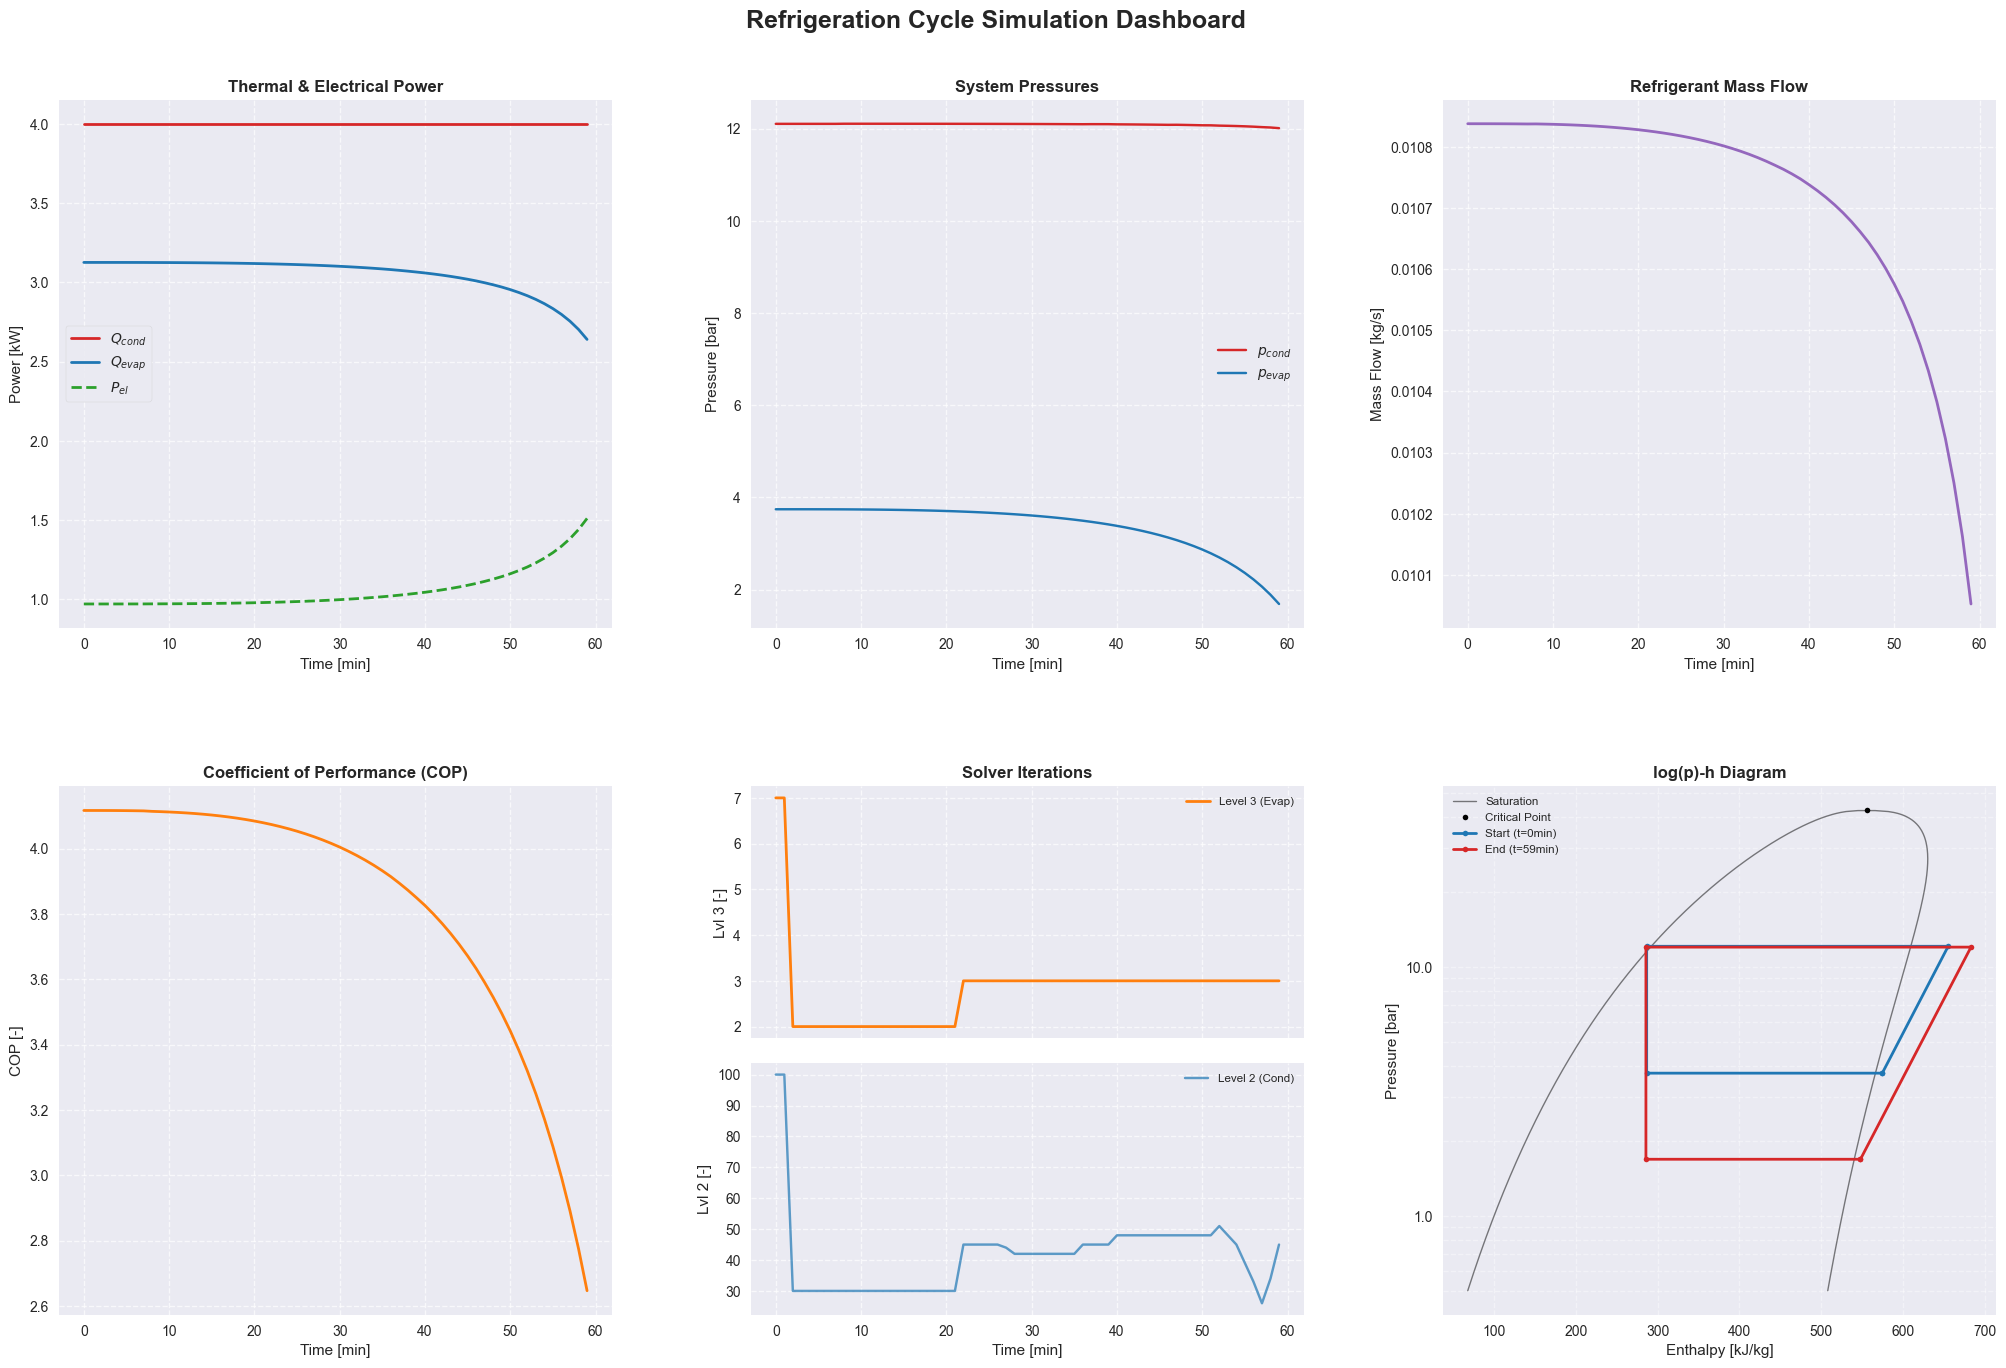

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =============================================================================
# DASHBOARD PLOTTING LOGIC
# =============================================================================

# Use a clean aesthetic style
plt.style.use('seaborn-v0_8') # 'bmh', 'seaborn-v0_8', or 'ggplot' work well for PowerPoint

# Create Figure
fig = plt.figure(figsize=(25, 15))
fig.suptitle('Refrigeration Cycle Simulation Dashboard', fontsize=18, fontweight='bold')

# Create Grid Spec (2 Rows, 3 Columns)
gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], wspace=0.25, hspace=0.3)

# -------------------------------------------------------------------------
# PLOT 1: Power & Heat (Top Left)
# -------------------------------------------------------------------------
ax1 = plt.subplot(gs[0, 0])
time_min = np.array(results["time"])

ax1.plot(time_min, np.array(results["Q_cond"])/1000, label='$Q_{cond}$', color='#d62728', linewidth=2)
ax1.plot(time_min, np.array(results["Q_evap"])/1000, label='$Q_{evap}$', color='#1f77b4', linewidth=2)
ax1.plot(time_min, np.array(results["P_el"])/1000, label='$P_{el}$', color='#2ca02c', linestyle='--', linewidth=2)

ax1.set_title('Thermal & Electrical Power', fontweight='bold')
ax1.set_ylabel('Power [kW]')
ax1.set_xlabel('Time [min]')
ax1.legend(loc='best', frameon=True)
ax1.grid(True, which='both', linestyle='--', alpha=0.7)

# -------------------------------------------------------------------------
# PLOT 2: Pressures (Top Center)
# -------------------------------------------------------------------------
ax2 = plt.subplot(gs[0, 1])

ax2.plot(time_min, np.array(results["p_cond"])/1e5, label='$p_{cond}$', color='#d62728')
ax2.plot(time_min, np.array(results["p_evap"])/1e5, label='$p_{evap}$', color='#1f77b4')

ax2.set_title('System Pressures', fontweight='bold')
ax2.set_ylabel('Pressure [bar]')
ax2.set_xlabel('Time [min]')
ax2.legend(loc='center right')
ax2.grid(True, linestyle='--', alpha=0.7)

# -------------------------------------------------------------------------
# PLOT 3: Mass Flow (Top Right)
# -------------------------------------------------------------------------
ax3 = plt.subplot(gs[0, 2])

ax3.plot(time_min, results["m_flow"], color='#9467bd', linewidth=2)

ax3.set_title('Refrigerant Mass Flow', fontweight='bold')
ax3.set_ylabel('Mass Flow [kg/s]')
ax3.set_xlabel('Time [min]')
ax3.grid(True, linestyle='--', alpha=0.7)

# -------------------------------------------------------------------------
# PLOT 4: COP (Bottom Left)
# -------------------------------------------------------------------------
ax4 = plt.subplot(gs[1, 0])

ax4.plot(time_min, results["COP"], color='#ff7f0e', linewidth=2)

ax4.set_title('Coefficient of Performance (COP)', fontweight='bold')
ax4.set_ylabel('COP [-]')
ax4.set_xlabel('Time [min]')
ax4.grid(True, linestyle='--', alpha=0.7)

import matplotlib.gridspec as gridspec

# -------------------------------------------------------------------------
# PLOT 5: Iterations (Bottom Center) - Nested Grid
# -------------------------------------------------------------------------
# Create nested grid
gs_inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[1, 1], hspace=0.1)
ax5_top = plt.subplot(gs_inner[0, 0])
ax5_bot = plt.subplot(gs_inner[1, 0], sharex=ax5_top) # Share X axis

# Plot Top Graph (Level 3)
ax5_top.plot(time_min, results["iterations"]["Level 3"], label='Level 3 (Evap)', color='tab:orange', linewidth=2)
ax5_top.set_title('Solver Iterations', fontweight='bold')
ax5_top.set_ylabel('Lvl 3 [-]')
ax5_top.grid(True, linestyle='--', alpha=0.7)
ax5_top.legend(loc='upper right', fontsize='small')
ax5_top.tick_params(labelbottom=False) 

# Plot Bottom Graph (Level 2)
ax5_bot.plot(time_min, results["iterations"]["Level 2"], label='Level 2 (Cond)', color='tab:blue', alpha=0.7)
ax5_bot.set_ylabel('Lvl 2 [-]')
ax5_bot.set_xlabel('Time [min]') # Label only on the bottom one
ax5_bot.grid(True, linestyle='--', alpha=0.7)
ax5_bot.legend(loc='upper right', fontsize='small')

# -------------------------------------------------------------------------
# PLOT 6: log(p)-h Diagram (Bottom Right)
# -------------------------------------------------------------------------
ax6 = plt.subplot(gs[1, 2])

# 1. Generate Saturation Dome
_, p_crit, _ = med_prop.get_critical_point()
# Go slightly closer to critical point (0.9995) to minimize the flat top gap
p_dome_range = np.logspace(np.log10(5e4), np.log10(p_crit * 0.999), 500)

h_liq_dome = []
h_vap_dome = []
p_dome_success = []  # Track pressures that actually succeed

for p in p_dome_range:
    try:
        # Calculate states
        hl = med_prop.calc_state("PQ", p, 0.0).h / 1000.0  # kJ/kg
        hv = med_prop.calc_state("PQ", p, 1.0).h / 1000.0  # kJ/kg
        
        h_liq_dome.append(hl)
        h_vap_dome.append(hv)
        p_dome_success.append(p)
    except:
        pass

# --- BRIDGE THE GAP ---
# Combine Liquid (Up) + Vapor (Down) into one continuous loop
h_dome_full = np.concatenate([h_liq_dome, h_vap_dome[::-1]])
p_dome_full = np.concatenate([p_dome_success, p_dome_success[::-1]])

# Plot the single continuous dome line
ax6.plot(h_dome_full, p_dome_full / 1e5, 'k-', linewidth=1, alpha=0.5, label='Saturation')

# Optional: Plot Critical Point Marker at the peak
if len(h_liq_dome) > 0:
    h_crit_est = (h_liq_dome[-1] + h_vap_dome[-1]) / 2
    ax6.plot(h_crit_est, p_crit / 1e5, 'ko', markersize=4, label='Critical Point')

# 2. Plot Cycles
colors = ['#1f77b4', '#d62728']  # Blue for start, Red for end
for idx, cycle in enumerate(results["cycles"]):
    h_cycle_kJ = np.array(cycle["h"]) / 1000.0
    p_cycle_bar = np.array(cycle["p"]) / 1e5
    
    ax6.plot(h_cycle_kJ, p_cycle_bar, color=colors[idx], linewidth=2, 
             label=cycle["name"], marker='.', markersize=8)

ax6.set_title('log(p)-h Diagram', fontweight='bold')
ax6.set_xlabel('Enthalpy [kJ/kg]')
ax6.set_ylabel('Pressure [bar]')
ax6.set_yscale('log')

# Format Y-axis log ticks nicely
from matplotlib.ticker import ScalarFormatter
ax6.yaxis.set_major_formatter(ScalarFormatter())

ax6.legend(loc='best', fontsize='small')
ax6.grid(True, which="both", ls="--", alpha=0.4)
# -------------------------------------------------------------------------
# FINAL LAYOUT ADJUSTMENTS
# -------------------------------------------------------------------------
plt.tight_layout()
plt.subplots_adjust(top=0.92) # Make room for main title

print("Displaying dashboard...")
plt.show()

## Test Heat Pump API

In [ ]:
from pathlib import Path
import sys
import os
import numpy as np

# Add project root to path
project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.append(project_root)

from frost_evaporator import FrostEvaporatorSimulation

def test_heatpump_api():
    # 1. Setup Simulation
    sim = FrostEvaporatorSimulation("config_OptiHorst.yaml")

    # ---------------------------------------------------------
    # Test Constants
    # ---------------------------------------------------------
    t_air = -1.0        # °C
    rh = 90.0          # %
    fan_rpm = 900     # RPM
    
    m_dot_ref = 0.024  # kg/s
    p_eva = 6e5      # Pa
    h_in = 280_000     # J/kg
    
    time_step_size = 60.0 # seconds

    print(f"--- Starting API Test ---")

    # ---------------------------------------------------------
    # 2. Prime the Model (Initialization)
    # ---------------------------------------------------------
    # Create the input object for t=0
    init_inputs = sim._create_inputs(t_air, rh, fan_rpm, h_in, p_eva, m_dot_ref)
    sim.prime_model(init_inputs)
    print("Model Primed.\n")

    # ---------------------------------------------------------
    # 3. Simulate Heat Pump Operation Loop
    # ---------------------------------------------------------
    # We simulate 3 time steps
    for t_step in range(1, 4):
        print(f"=== Time Step {t_step} (t={t_step*time_step_size/60:.1f} min) ===")

        # A. Convergence Loop (The Heat Pump finding its operating point)
        # In a real HP model, p_eva or m_dot would change here. We just iterate to test stability.
        for iteration in range(3):
            
            # Call the performance calculator (Stateless regarding frost, purely thermodynamic)
            h_out = sim.calculate_performance(
                T_air_C=t_air,
                RH_pct=rh,
                fan_rpm=fan_rpm,
                h_ref=h_in,
                p_ref_Pa=p_eva,
                m_dot_ref=m_dot_ref,
                time_step_s=time_step_size
            )
            
            # Calculate simple capacity for feedback
            capacity = m_dot_ref * (h_out - h_in)
            print(f"   [Iter {iteration}] Outlet Enthalpy: {h_out:.2f} J/kg | Capacity: {capacity:.1f} W")

        # B. Advance Simulation (Frost Growth)
        # Once the HP is happy with h_out, we lock it in and grow frost
        print("   -> Converged. Advancing Frost Growth...")
        current_states = sim.advance_simulation_step()
        
        # Log something from the state to prove it updated
        frost_thickness_L1 = current_states[0].frost.thickness
        print(f"   -> Step Complete. L1 Frost Thickness: {frost_thickness_L1*1000:.4f} mm\n")

if __name__ == "__main__":
    test_heatpump_api()